# Уравнение Релея: 


Система:
$$x' = v,\qquad v' = \mu(1-v^2)v - x,$$
$$x(0)=0,\qquad v(0)=0.001,\qquad \mu=1000.$$

In [57]:
params = dict(
    mu=1000.0,
    t0=0.0,
    T=1000.0,
    x0=0.0,
    v0=0.001,
    h=1e-3,
    sample_stride=2000,
)
from zhectkie import *

## Решение

In [58]:
df = run_all_parallel(params)
df

,method,t_final,x_T,v_T
0,ImplicitEulerSolver,1000.0,-182.794290,-0.891621
1,RadauIIA3Solver,1000.0,-182.783454,-0.891628
2,RadauIIA5Solver,1000.0,-182.783571,-0.891628
3,SDIRK2Solver,1000.0,-182.785854,-0.891627


In [59]:
cmp_df = compare_with_reference(df, ref_method='RadauIIA5Solver')
cmp_df

,method,t_final,x_T,v_T,|x_T - x_ref|,|v_T - v_ref|
0,ImplicitEulerSolver,1000.0,-182.794290,-0.891621,0.010720,7.739841e-06
1,RadauIIA3Solver,1000.0,-182.783454,-0.891628,0.000117,8.439676e-08
2,RadauIIA5Solver,1000.0,-182.783571,-0.891628,0.000000,0.000000e+00
3,SDIRK2Solver,1000.0,-182.785854,-0.891627,0.002283,1.648248e-06


## Области устойчивости

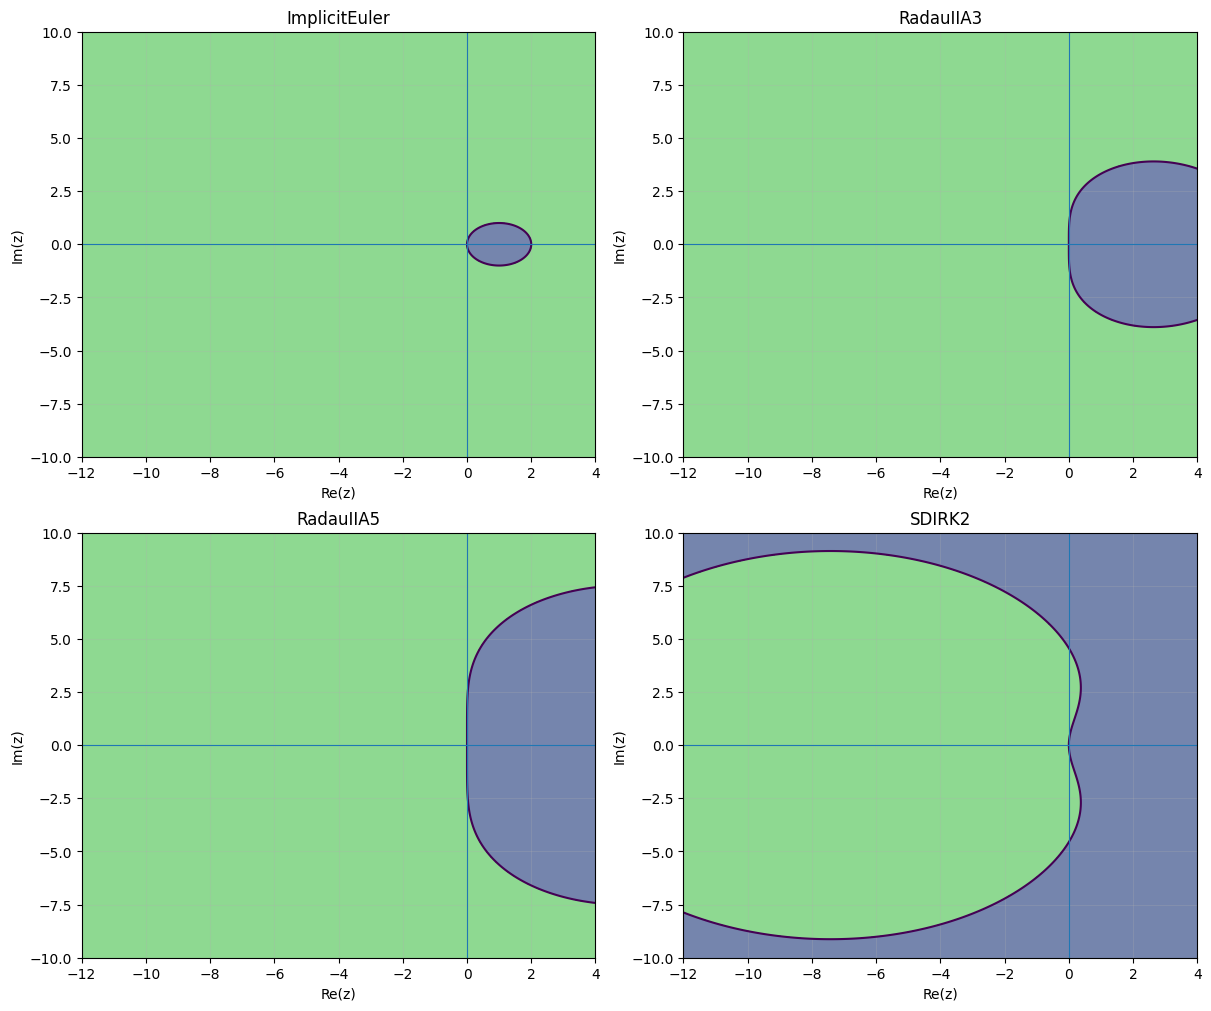

In [63]:
fig = plot_stability_regions(['ImplicitEuler', 'RadauIIA3', 'RadauIIA5', 'SDIRK2'])
plt.show()

# Провека предела функции устойчивости на беск

In [61]:
import numpy as np
import pandas as pd

methods = ["ImplicitEuler", "RadauIIA3", "RadauIIA5", "SDIRK2"]

xs = np.array([1, 10, 100, 1000, 10000, 100000], dtype=float)

rows = []
for name in methods:
    A, b = get_butcher_tableau(name)
    vals = [stability_function(A, b, -x + 0j) for x in xs]
    row = {"method": name}
    for x, val in zip(xs, vals):
        row[f"|R(-{int(x)})|"] = abs(val)
    rows.append(row)

limit_check_df = pd.DataFrame(rows)
limit_check_df

,method,|R(-1)|,|R(-10)|,|R(-100)|,|R(-1000)|,|R(-10000)|,|R(-100000)|
0,ImplicitEuler,0.500000,0.090909,0.009901,0.000999,0.000100,0.000010
1,RadauIIA3,0.363636,0.095890,0.018643,0.001986,0.000200,0.000020
2,RadauIIA5,0.367925,0.051724,0.025291,0.002949,0.000299,0.000030
3,SDIRK2,0.438050,0.745151,1.552189,1.690725,1.705459,1.706942


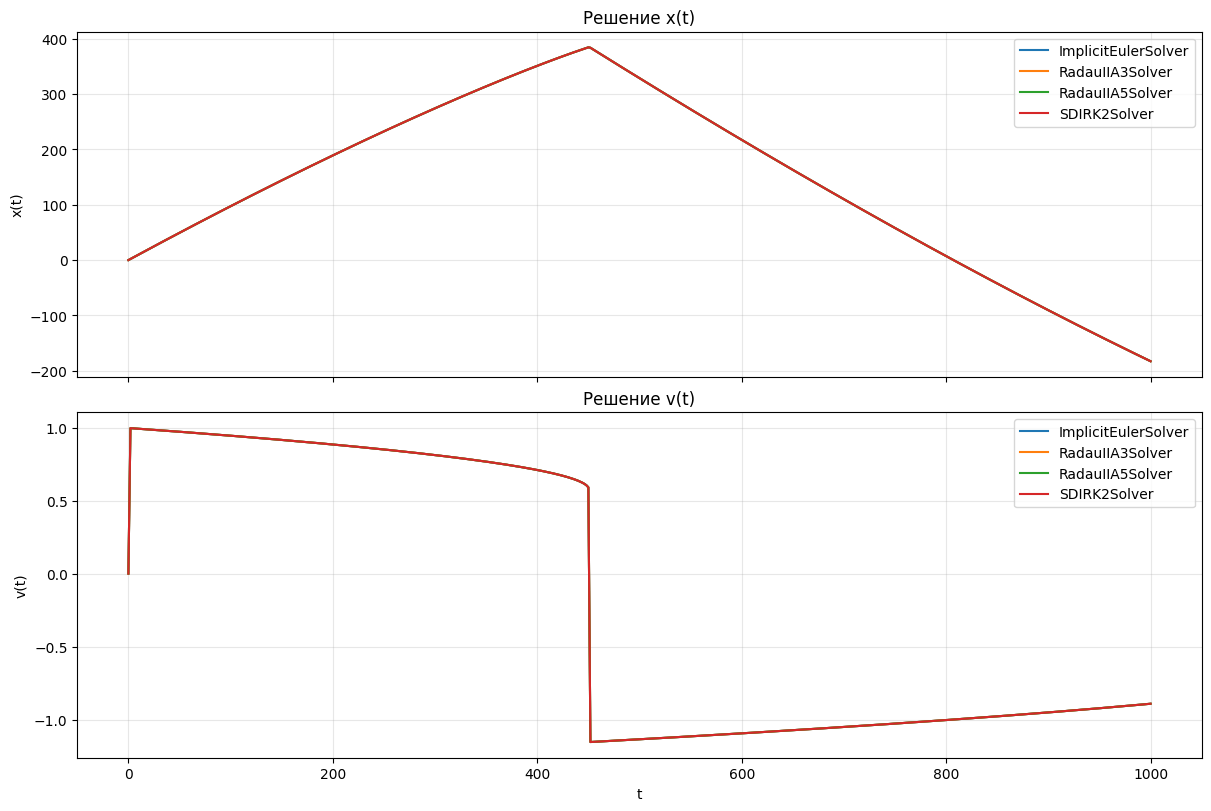

In [67]:
from zhectkie import *
def plot_solutions_vs_time_combined(params, methods=None):
    if methods is None:
        methods = [
            ImplicitEulerSolver,
            RadauIIA3Solver,
            RadauIIA5Solver,
            SDIRK2Solver,
        ]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)

    for solver_cls in methods:
        solver = solver_cls(**params)
        t, y = solver.solve(keep_history=True)
        axes[0].plot(t, y[:, 0], label=solver_cls.__name__)
        axes[1].plot(t, y[:, 1], label=solver_cls.__name__)

    axes[0].set_title("Решение x(t)")
    axes[0].set_ylabel("x(t)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Решение v(t)")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("v(t)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    return fig
fig = plot_solutions_vs_time_combined(params)
plt.show()